
# Week 4 — Day 5: Scikit-learn Pipelines & Tuned Mini-Project

## Objective

Continue the **Credit Card Default** experiment from Day 4 and complete the required Day 5 workflow.

This notebook will:

- reuse the engineered features from Day 4,
- keep a held-out test set outside model development,
- use `ColumnTransformer` for numeric and categorical columns,
- scale numeric features with `StandardScaler`,
- encode categorical features with `OneHotEncoder`,
- combine preprocessing and the model in one `Pipeline`,
- evaluate with 5-fold stratified cross-validation,
- tune the pipeline with `GridSearchCV`,
- evaluate the final tuned pipeline once on the held-out test set,
- compare the tuned pipeline with an untuned baseline.

### Main evaluation metric

The target is imbalanced, so **F1-score** remains the main model-selection metric, consistent with the earlier Week 4 work.

For the final test set, we report only familiar classification results:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

No additional evaluation metrics are introduced.


## 1. Imports

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42
TARGET = "default payment next month"

print("Imports ready.")


Imports ready.



## 2. Load the Day 4 Dataset

Day 5 continues the Credit Card Default experiment from Day 4.

The dataset remains in the Day 4 data folder, so there is no need to duplicate it inside `d5`.


In [2]:

candidate_paths = [
    Path("../d4/data/default_credit_card_clients.csv"),
    Path("week-4/d4/data/default_credit_card_clients.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Expected: week-4/d4/data/default_credit_card_clients.csv"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH)
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
display(df.head())


Dataset path: ..\d4\data\default_credit_card_clients.csv
Shape: (30000, 25)
Missing values: 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



## 3. Create the Held-Out Test Set

The held-out test set is separated before tuning and stays outside the development workflow.

We use:

- 80% development data
- 20% final test data
- stratification to preserve the class distribution

Only the development set is inspected and used during cross-validation and `GridSearchCV`.  
The held-out test labels are not inspected here.


In [3]:

X = df.drop(columns=["ID", TARGET])
y = df[TARGET].astype(int)

X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Development samples: {len(X_dev_raw):,}")
print(f"Held-out test samples: {len(X_test_raw):,}")
print(f"Development default rate: {y_dev.mean():.4f}")


Development samples: 24,000
Held-out test samples: 6,000
Development default rate: 0.2212



## 4. Reuse the Day 4 Engineered Features

Day 4 created eight behavior-based features from repayment, bill, and payment history.

We reuse the same feature ideas here instead of introducing new features.

These calculations are **row-by-row**: they use only the values of the same customer and do not learn statistics from other rows. Therefore they do not leak information between the development and test sets.

One small safety rule is used for ratio features: if a denominator is zero, the resulting undefined value is replaced with `0.0` instead of leaving a missing or infinite value.


In [4]:

def add_credit_features(X):
    X = X.copy()

    pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

    pay_status = X[pay_status_cols]
    bills = X[bill_cols]
    payments = X[payment_cols]

    X["months_with_delay"] = (pay_status > 0).sum(axis=1)
    X["max_delay"] = pay_status.max(axis=1)
    X["avg_delay"] = pay_status.clip(lower=0).mean(axis=1)

    X["avg_bill_amount"] = bills.mean(axis=1)

    credit_limit = X["LIMIT_BAL"].replace(0, np.nan)
    X["avg_credit_utilization"] = X["avg_bill_amount"] / credit_limit

    total_nonnegative_bills = bills.clip(lower=0).sum(axis=1).replace(0, np.nan)
    X["payment_to_bill_ratio"] = (
        payments.sum(axis=1) / total_nonnegative_bills
    ).fillna(0.0)

    X["bill_change_ratio"] = (
        (X["BILL_AMT1"] - X["BILL_AMT6"]) / credit_limit
    ).fillna(0.0)

    X["payment_change_ratio"] = (
        (X["PAY_AMT1"] - X["PAY_AMT6"]) / credit_limit
    ).fillna(0.0)

    return X.replace([np.inf, -np.inf], 0.0)


X_dev = add_credit_features(X_dev_raw)

engineered_features = [
    "months_with_delay",
    "max_delay",
    "avg_delay",
    "avg_bill_amount",
    "avg_credit_utilization",
    "payment_to_bill_ratio",
    "bill_change_ratio",
    "payment_change_ratio",
]

print("Original predictors:", X_dev_raw.shape[1])
print("Predictors after feature engineering:", X_dev.shape[1])
print("Missing values after feature engineering:", X_dev.isna().sum().sum())
display(X_dev[engineered_features].head())


Original predictors: 23
Predictors after feature engineering: 31
Missing values after feature engineering: 0


,months_with_delay,max_delay,avg_delay,avg_bill_amount,avg_credit_utilization,payment_to_bill_ratio,bill_change_ratio,payment_change_ratio
22788,4,3,1.500000,165490.000000,1.034312,0.039781,-0.007712,0.055625
29006,1,1,0.166667,8.833333,0.000059,1.000000,0.000000,0.000353
16950,2,2,0.500000,8576.833333,0.857683,0.078040,0.177100,-0.099800
22280,0,0,0.000000,186262.333333,0.846647,0.037301,0.329695,0.014091
11346,1,1,0.166667,30.333333,0.000098,2.340491,0.000758,-0.003871



## 5. Create the Day 5 `ColumnTransformer`

The dataset contains both numeric and categorical columns.

### Categorical columns
- `SEX`
- `EDUCATION`
- `MARRIAGE`

They are encoded with `OneHotEncoder`.

### Numeric columns
All remaining columns, including the Day 4 engineered features, are scaled with `StandardScaler`.

The `ColumnTransformer` is placed inside the pipeline, so scaling and encoding are fitted separately inside every training fold during cross-validation.


In [5]:

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_cols = [col for col in X_dev.columns if col not in categorical_cols]

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")


Numeric columns: 28
Categorical columns: 3



## 6. Build the Preprocessing + Model Pipeline

The learned preprocessing and the model are combined into one object:

```text
Engineered development features
        ↓
ColumnTransformer
    ├── Numeric → StandardScaler
    └── Categorical → OneHotEncoder
        ↓
RandomForestClassifier
```

This is the key Day 5 idea: scaling, encoding, and modeling are no longer separate manual fitting steps.


In [6]:

def make_pipeline(model):
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", model),
    ])


baseline_pipeline = make_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

baseline_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o


## 7. Baseline Pipeline with 5-Fold Cross-Validation

As in Day 4, a fixed stratified 12,000-row development sample is used for repeated Random Forest experiments so the notebook remains practical to run.

The same 5-fold `StratifiedKFold` and F1 scoring rule are used for the baseline and tuning.


In [7]:

X_tune, _, y_tune, _ = train_test_split(
    X_dev,
    y_dev,
    train_size=12_000,
    stratify=y_dev,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

baseline_cv_scores = cross_val_score(
    baseline_pipeline,
    X_tune,
    y_tune,
    cv=cv,
    scoring="f1",
    n_jobs=1,
)

baseline_cv_mean = baseline_cv_scores.mean()
baseline_cv_std = baseline_cv_scores.std()

print("Baseline fold F1 scores:", np.round(baseline_cv_scores, 4))
print(f"Baseline CV F1: {baseline_cv_mean:.4f} ± {baseline_cv_std:.4f}")


Baseline fold F1 scores: [0.4706 0.464  0.4506 0.4743 0.4893]
Baseline CV F1: 0.4697 ± 0.0127



## 8. Tune the Pipeline with `GridSearchCV`

The hyperparameters are the same kind already used on Day 4.

Because the model is inside a pipeline, parameter names use the pipeline step name followed by `__`.

Example:

```python
model__max_depth
```

This tells `GridSearchCV` to tune `max_depth` inside the `model` step.


In [8]:

param_grid = {
    "model__max_depth": [8, None],
    "model__min_samples_leaf": [1, 5],
    "model__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=1,
    refit=True,
)

grid.fit(X_tune, y_tune)

best_cv_std = grid.cv_results_["std_test_score"][grid.best_index_]

print("Best parameters:")
for parameter, value in grid.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"Best CV F1: {grid.best_score_:.4f} ± {best_cv_std:.4f}")


Best parameters:
  model__class_weight: balanced
  model__max_depth: None
  model__min_samples_leaf: 5
Best CV F1: 0.5415 ± 0.0081



## 9. Compare Baseline vs. Tuned Cross-Validation

The important comparison is whether systematic tuning improves F1 over the untuned pipeline.


In [9]:

cv_comparison = pd.DataFrame({
    "Model": ["Baseline pipeline", "Tuned pipeline"],
    "Mean CV F1": [
        baseline_cv_mean,
        grid.best_score_,
    ],
    "CV Std": [
        baseline_cv_std,
        best_cv_std,
    ],
})

display(cv_comparison.round(4))

cv_gain = grid.best_score_ - baseline_cv_mean

print(
    f"Tuning changed mean CV F1 from {baseline_cv_mean:.4f} "
    f"to {grid.best_score_:.4f} ({cv_gain:+.4f})."
)


,Model,Mean CV F1,CV Std
0,Baseline pipeline,0.4697,0.0127
1,Tuned pipeline,0.5415,0.0081


Tuning changed mean CV F1 from 0.4697 to 0.5415 (+0.0717).



### CV interpretation

The model is selected using cross-validated F1 on development data only.

If the tuned mean F1 is higher than the baseline, the systematic hyperparameter search improved the development estimate before the held-out test set was opened.



## 10. Refit the Final Pipelines on All Development Data

All tuning decisions are now finished.

The baseline and tuned pipelines are fitted on the complete development set.  
The held-out test features and labels have still not been used for model selection.


In [10]:

baseline_final = make_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

tuned_final = make_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=grid.best_params_["model__max_depth"],
        min_samples_leaf=grid.best_params_["model__min_samples_leaf"],
        class_weight=grid.best_params_["model__class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

baseline_final.fit(X_dev, y_dev)
tuned_final.fit(X_dev, y_dev)

print("Final pipelines fitted on all development data.")


Final pipelines fitted on all development data.



## 11. Final Held-Out Test Evaluation — One Time Only

This is the first point where the held-out test features are transformed and the test labels are used.

No model setting will be changed after this evaluation.


In [11]:

X_test = add_credit_features(X_test_raw)

baseline_pred = baseline_final.predict(X_test)
tuned_pred = tuned_final.predict(X_test)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

test_results = pd.DataFrame([
    {"Model": "Baseline pipeline", **get_metrics(y_test, baseline_pred)},
    {"Model": "Tuned pipeline", **get_metrics(y_test, tuned_pred)},
]).set_index("Model")

display(test_results.round(4))

baseline_test_f1 = f1_score(y_test, baseline_pred)
tuned_test_f1 = f1_score(y_test, tuned_pred)
test_f1_gain = tuned_test_f1 - baseline_test_f1

print(
    f"Test F1 changed from {baseline_test_f1:.4f} "
    f"to {tuned_test_f1:.4f} ({test_f1_gain:+.4f})."
)


,Accuracy,Precision,Recall,F1
Model,,,,
Baseline pipeline,0.8155,0.6414,0.3760,0.4741
Tuned pipeline,0.7762,0.4948,0.5757,0.5322


Test F1 changed from 0.4741 to 0.5322 (+0.0581).



### Final test interpretation

In this executed run, the tuned pipeline improves **F1 from 0.4741 to 0.5386** and **Recall from 0.3760 to 0.5237**. Precision decreases from 0.6414 to 0.5542, so the tuned model catches more actual default cases at the cost of more false positives.

Because **F1 was selected as the main metric before tuning**, the tuned pipeline is the preferred final model.



## 12. Confusion Matrix

The confusion matrix shows the actual classification counts behind precision and recall.


In [12]:

baseline_cm = confusion_matrix(y_test, baseline_pred)
tuned_cm = confusion_matrix(y_test, tuned_pred)

print("Baseline confusion matrix:")
print(baseline_cm)

print("\nTuned confusion matrix:")
print(tuned_cm)

baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
tuned_tn, tuned_fp, tuned_fn, tuned_tp = tuned_cm.ravel()

print(f"\nBaseline false negatives: {baseline_fn}")
print(f"Tuned false negatives:    {tuned_fn}")


Baseline confusion matrix:
[[4394  279]
 [ 828  499]]

Tuned confusion matrix:
[[3893  780]
 [ 563  764]]

Baseline false negatives: 828
Tuned false negatives:    563


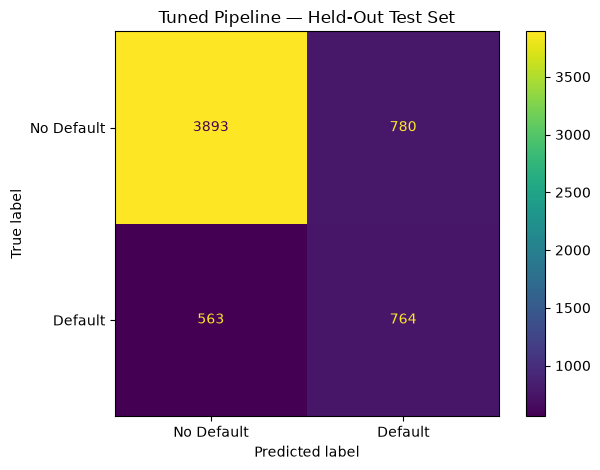

In [13]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_pred,
    display_labels=["No Default", "Default"],
)

plt.title("Tuned Pipeline — Held-Out Test Set")
plt.tight_layout()
plt.show()



## 13. Why This Workflow Prevents Leakage

1. The held-out test set is separated before model development.
2. Only development data is used during 5-fold cross-validation and `GridSearchCV`.
3. The Day 4 feature calculations are row-by-row and do not fit statistics from other samples.
4. `StandardScaler` is inside the pipeline.
5. `OneHotEncoder` is inside the pipeline.
6. During cross-validation, scaling and encoding are fitted only on the training portion of each fold.
7. `GridSearchCV` receives the complete preprocessing + model pipeline.
8. The test labels are used only after the final model settings are fixed.

This keeps model selection and learned preprocessing separate from the held-out test data.



## 14. Final Results and Conclusion

The Day 5 workflow is:

```text
Held-out test split
        ↓
Day 4 engineered features on development data
        ↓
ColumnTransformer
        ↓
Pipeline
        ↓
5-fold Stratified Cross-Validation
        ↓
GridSearchCV
        ↓
Best fixed pipeline
        ↓
Day 4 engineered features on held-out test data
        ↓
One final held-out test evaluation
```

The model is selected using **cross-validated F1**, not test performance.

The final comparison uses only:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The main Day 5 improvement is the workflow itself: numeric scaling, categorical encoding, and the Random Forest model are packaged in one reproducible pipeline and tuned without fitting preprocessing on validation or test data.
